In [59]:
import numpy as np
import matplotlib.pyplot as plt
import numba
from numba import njit

In [93]:
def tune_sigma(lattice, positions, T, N, initial_sigma=np.pi/8, target=0.5, tune_steps=1000):

    sigma = initial_sigma
    for _ in range(10):  # максимум 10 итераций
        accepted = 0
        temp_lattice = lattice.copy()
        for _ in range(tune_steps):
            _, acc = metropolis_step(temp_lattice, positions, T, N, sigma)
            if acc:
                accepted += 1
        acceptance = accepted / tune_steps

        if acceptance > target + 0.05:
            sigma *= 1.1
        elif acceptance < target - 0.05:
            sigma *= 0.9
        else:
            break
    return sigma

In [61]:
                                            #ТЕОРИЯ

In [62]:
def create_lattice(N):
     return np.random.uniform(0, 2*np.pi, size=(N, N)) #np.random.uniform()-генерирует равномерно распределенные случаные числа

In [63]:
def build_lattice_positions(N):
    x= np.arange(N)
    y= np.arange(N)
    xx, yy = np.meshgrid(x, y)
    positions = np.column_stack([xx.ravel(), yy.ravel()]) #превращаем матрицу координат в одномерный массив
    return positions #возвращает координаты

In [64]:
def idx_to_ij(idx, N): #индекс в координаты
    return idx // N, idx % N

In [65]:
def ij_to_idx(i, j, N): #наоборот
    return i * N + j

In [66]:
def angle_to_vector(angle): #угол в вектор
    return np.array([np.cos(angle), np.sin(angle)])

In [67]:
def get_distance(idx1, idx2, positions, N, a=1.0): #задаем расстояние между диполями

    pos_1 = positions[idx1]
    pos_2 = positions[idx2]

    dx = pos_2[0] - pos_1[0]
    dy = pos_2[1] - pos_1[1]

    r = np.sqrt(dx**2 + dy**2)
    r_vec = np.array([dx, dy]) * a
    return r_vec, r

In [68]:
@numba.njit#("UniTuple(f8[:], 2)(f8[:], i8, f8)", nopython=True, nogil=True)
#U=(p_1*p_2)/r^3 - 3(p_1*r)(p_2*r)/r^5
def pair_energy(p_1, p_2, r_vec, r):

    if r < 1e-10:
        return 0.0

    r3 = r ** 3
    r5 = r ** 5
    pp = p_1[0]*p_2[0] + p_1[1]*p_2[1]
    p_1r = p_1[0]*r_vec[0] + p_1[1]*r_vec[1]
    p_2r = p_2[0]*r_vec[0] + p_2[1]*r_vec[1]
    return pp / r3 - 3 * p_1r * p_2r / r5

In [69]:
def total_energy(lattice, positions, N):
    energy = 0.0

    for idx1 in range(N * N):
        i_1, j_1 = idx_to_ij(idx1, N)
        angle1 = lattice[i_1, j_1]
        p_1 = angle_to_vector(angle1)

        for idx2 in range(idx1 + 1, N * N):
            i_2, j_2 = idx_to_ij(idx2, N)
            angle2 = lattice[i_2, j_2]
            p_2 = angle_to_vector(angle2)

            r_vec, r = get_distance(idx1, idx2, positions, N)

            energy += pair_energy(p_1, p_2, r_vec, r)

    return energy

In [70]:
def total_dipole_moment(lattice, N):
        P_x = 0.0
        P_y = 0.0

        for i in range(N):
            for j in range(N):
                angle = lattice[i, j]
                P_x += np.cos(angle)
                P_y += np.sin(angle)

        return np.array([P_x, P_y]), np.sqrt(P_x ** 2 + P_y ** 2)

In [71]:
def energy_change(lattice, positions, idx, new_angle, N):

    i, j = idx_to_ij(idx, N)
    old_angle = lattice[i, j]
    old_p = angle_to_vector(old_angle)
    new_p = angle_to_vector(new_angle)

    delta = 0.0

    for other_idx in range(N * N):
            if other_idx == idx:
                continue

            x, y = idx_to_ij(other_idx, N)
            other_angle = lattice[x, y]
            other_p = angle_to_vector(other_angle)

            r_vec, r = get_distance(idx, other_idx, positions, N)

            U_old = pair_energy(old_p, other_p, r_vec, r)
            U_new = pair_energy(new_p, other_p, r_vec, r)

            delta += (U_new - U_old)

    return delta

In [72]:
def metropolis_step(lattice, positions, T, N, sigma=np.pi/10):

    beta = 1.0 / T
    idx = np.random.randint(0, N * N) # выбираем случайный диполь
    i, j = idx_to_ij(idx, N)

    old_angle = lattice[i, j]
    new_angle = old_angle + np.random.normal(0, sigma)
    new_angle = new_angle % (2 * np.pi)  # приводим в диапазон [0, 2π)

    delta_E = energy_change(lattice, positions, idx, new_angle, N)  # считаем изменение энергии

    #Метрополис
    if delta_E < 0:
        lattice[i, j] = new_angle
        return delta_E, True
    else:
        probability = np.exp(-beta * delta_E)
        if np.random.random() < probability:
            lattice[i, j] = new_angle
            return delta_E, True
        else:
            return delta_E, False

In [73]:
def monte_carlo_sweep(lattice, positions, T, N, sigma):
    accepted_count = 0
    for _ in range(N * N):
        _, is_accepted = metropolis_step(lattice, positions, T, N, sigma)
        if is_accepted:
            accepted_count += 1
    return accepted_count

In [74]:
                                #МОДЕЛИРОВАНИЕ

In [75]:
def simulate_simple(lattice, positions, T, N, sigma, mc_steps=5000, burn_in=1000):

    # Прогрев
    for _ in range(burn_in):
        monte_carlo_sweep(lattice, positions, T, N, sigma)

    history = []
    total_accepted = 0
    total_steps = 0

    for _ in range(mc_steps):
        accepted = monte_carlo_sweep(lattice, positions, T, N, sigma)
        total_accepted += accepted
        total_steps += N * N

        _, P = total_dipole_moment(lattice, N)
        P = P / (N * N)
        E = total_energy(lattice, positions, N)
        history.append((P, E))

    acceptance_rate = total_accepted / total_steps
    print(f"Частота принятия = {acceptance_rate:.2f}")

    return history

In [76]:
def simulate_multiple(N, T, n_runs, mc_steps, burn_in, sigma):
    P_results = [] # создаем пустые списки
    E_results = [] # создаем пустые списки

    #print(f"\n  Запуск {n_runs} прогонов при T={T}...")

    for run in range(n_runs):
        #создаем новую решетку для каждого нового прогона
        lattice = create_lattice(N)
        positions = build_lattice_positions(N)

        history = simulate_simple(lattice, positions, T, N, sigma, mc_steps, burn_in) #записываем в историю результаты каждого прогона

        P_final, E_final = history[-1]#берем последнее значение

        P_results.append(P_final) #записываем в наши списки конечные значения каждого прогона
        E_results.append(E_final)

        #print(f"    Прогон {run+1}/{n_runs} → ⟨p⟩ = {P_final:.4f}, E = {E_final:.4f}")

    return P_results, E_results

In [92]:
def run_fluctuations(N=4, T=1.0, n_runs=4, mc_steps=100, burn_in=50, sigma=np.pi/8):

    print("Анализ флуктуаций")
    print(f"Решетка: {N}×{N} = {N*N} диполей")
    print(f"Температура: T = {T}")
    print(f"Количество прогонов: {n_runs}")

    P_results, E_results = simulate_multiple(N, T, n_runs, mc_steps, burn_in, sigma)
    print_statistics(P_results, E_results)
    plot_fluctuations(P_results, E_results, N, T)

In [78]:
def plot_fluctuations(P_values, E_values, N, T):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) #создали окошко (главное в него не выйти)

    #гистограмма поляризации
    ax1.hist(P_values, bins=15, edgecolor='black', alpha=0.7, color='green')
    ax1.axvline(x=np.mean(P_values), color='red', linestyle='--',
                label=f'Среднее = {np.mean(P_values):.4f}')#на уровне среднего значения
    ax1.set_xlabel(f'Конечный средний дипольный момент ⟨p⟩')
    ax1.set_ylabel('Частота')
    ax1.set_title(f'Флуктуации поляризации\n(N={N}×{N}, T={T})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #гистограмма энергии
    ax2.hist(E_values, bins=15, edgecolor='black', alpha=0.7, color='orange')
    ax2.axvline(x=np.mean(E_values), color='red', linestyle='--',
                label=f'Среднее = {np.mean(E_values):.4f}')
    ax2.set_xlabel('Конечная энергия E')
    ax2.set_ylabel('Частота')
    ax2.set_title(f'Флуктуации энергии\n(N={N}×{N}, T={T})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout() #подгонка рисунков, чтобы не находили друг на друга
    plt.show()

In [79]:
def print_statistics(P_values, E_values):
    print("Статистика")
    print("\nПоляризация ⟨p⟩:")
    print(f"  Среднее = {np.mean(P_values):.4f}") #Среднее арифметическое всех значений поляризации
    print(f"  Стандартное отклонение = {np.std(P_values):.4f}") #Стандартное отклонение (мера разброса)
    print(f"  Минимум = {np.min(P_values):.4f}") #min
    print(f"  Максимум = {np.max(P_values):.4f}") #max

    print("\nЭнергия E:")
    print(f"  Среднее = {np.mean(E_values):.4f}")
    print(f"  Стандартное отклонение = {np.std(E_values):.4f}")
    print(f"  Минимум = {np.min(E_values):.4f}")
    print(f"  Максимум = {np.max(E_values):.4f}")

In [88]:
def run_temperature_dependence(N=5, temperatures=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
                                n_runs=5, mc_steps=80, burn_in=400, sigma=np.pi/8):
    print("зависимость от температуры")
    print(f"  Решетка: {N}×{N} = {N*N} диполей")
    print(f"  Диапазон температур: {temperatures}")
    print(f"  Прогонов на температуру: {n_runs}")

    P_means = []  # средние значения поляризации для каждой T
    P_stds = []   # стандартные отклонения поляризации
    E_means = []  # средние значения энергии для каждой T
    E_stds = []   # стандартные отклонения энергии
    sigma_values = []

    for T in temperatures:
        print(f"Температура T = {T}")
        temp_lattice = create_lattice(N)
        positions_temp = build_lattice_positions(N)

        sigma_tuned = tune_sigma(temp_lattice, positions_temp, T, N, initial_sigma=sigma)
        sigma_values.append(sigma_tuned)
        print(f"  Подобранная sigma = {sigma_tuned:.3f} рад ({sigma_tuned*180/np.pi:.1f}°)")
        P_vals = [] # создаем пустые списки
        E_vals = [] # создаем пустые списки(like me)

        #несколько прогонов при одной температуре
        for run in range(n_runs):
            lattice = create_lattice(N)
            positions = build_lattice_positions(N)

            # Прогрев
            for _ in range(burn_in):
                monte_carlo_sweep(lattice, positions, T, N, sigma_tuned)
            # Основные шаги
            for _ in range(mc_steps):
                monte_carlo_sweep(lattice, positions, T, N, sigma_tuned)

            _, P = total_dipole_moment(lattice, N)
            P = P / (N * N)
            E = total_energy(lattice, positions, N)

            P_vals.append(P)
            E_vals.append(E)
            print(f"  Прогон {run+1}/{n_runs} → ⟨p⟩ = {P:.4f}, E = {E:.4f}")

        P_means.append(np.mean(P_vals))
        P_stds.append(np.std(P_vals))
        E_means.append(np.mean(E_vals))
        E_stds.append(np.std(E_vals))
        print(f"  → Среднее ⟨p⟩ = {P_means[-1]:.4f} ± {P_stds[-1]:.4f}") #графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.errorbar(temperatures, P_means, yerr=P_stds, fmt='o-', capsize=5,
                     color='blue', ecolor='lightblue', markersize=8)
    ax1.set_xlabel('Температура T')
    ax1.set_ylabel('Средний дипольный момент ⟨p⟩')
    ax1.set_title('Зависимость поляризации от температуры')
    ax1.grid(True, alpha=0.3)

    ax2.errorbar(temperatures, E_means, yerr=E_stds, fmt='s-', capsize=5,
                     color='green', ecolor='lightgreen', markersize=8)
    ax2.set_xlabel('Температура T')
    ax2.set_ylabel('Энергия E')
    ax2.set_title('Зависимость энергии от температуры')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

 #итоговая таблица
    print("Итог")
    print(f"{'T':>6} | {'⟨p⟩':>12} | {'σ_p':>10} | {'E':>12} | {'σ_E':>10}")
    for i, T in enumerate(temperatures):
        print(f"{T:6.2f} | {P_means[i]:12.4f} | {P_stds[i]:10.4f} | "
                 f"{E_means[i]:12.4f} | {E_stds[i]:10.4f}")

In [83]:
                                     #ЗАПУСК

Анализ флуктуаций
Решетка: 5×5 = 25 диполей
Температура: T = 1.0
Количество прогонов: 10
Частота принятия = 0.72
Частота принятия = 0.72
Частота принятия = 0.73
Частота принятия = 0.72
Частота принятия = 0.73
Частота принятия = 0.73
Частота принятия = 0.74
Частота принятия = 0.73
Частота принятия = 0.74
Частота принятия = 0.72
Статистика

Поляризация ⟨p⟩:
  Среднее = 0.1614
  Стандартное отклонение = 0.1376
  Минимум = 0.0377
  Максимум = 0.5189

Энергия E:
  Среднее = -37.9485
  Стандартное отклонение = 3.1682
  Минимум = -42.5035
  Максимум = -32.7141


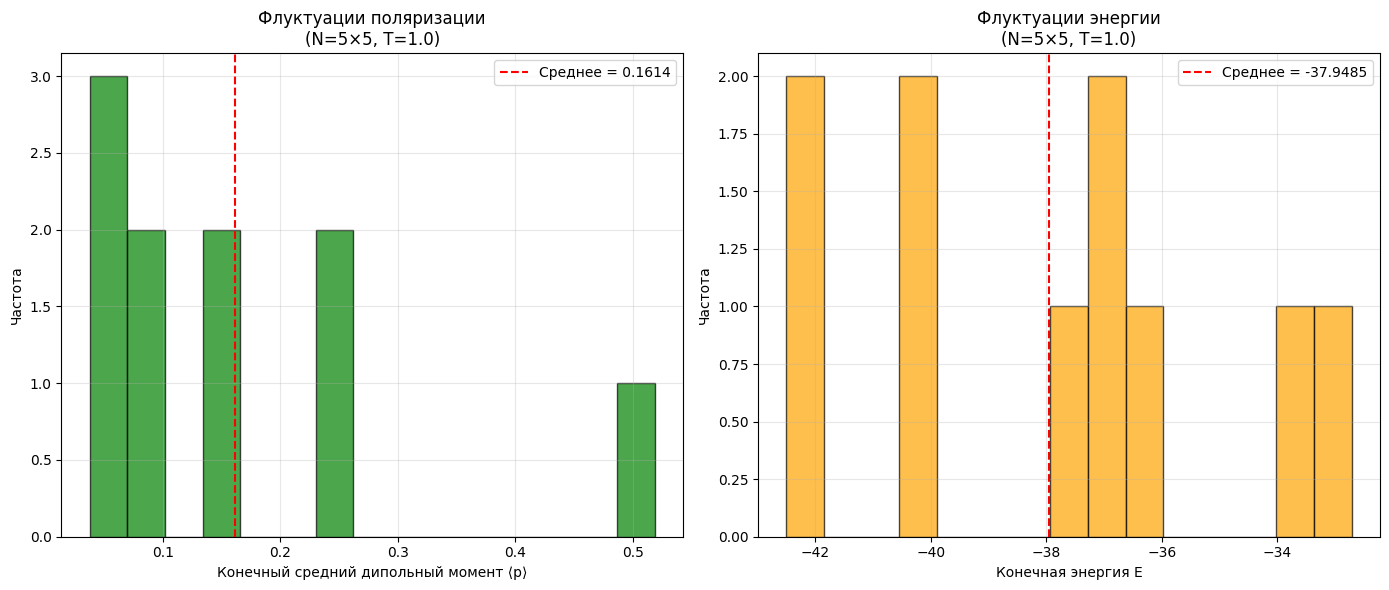

In [98]:
if __name__ == "__main__":
    N=5
    T=1.0
    n_runs=40
    mc_steps=10000
    burn_in=2000
    sigma=np.pi/3


    run_fluctuations(N, T, n_runs, mc_steps, burn_in, sigma)           # флуктуации при T=1.0

зависимость от температуры
  Решетка: 5×5 = 25 диполей
  Диапазон температур: [0.04, 0.5, 1.0, 5, 15, 40]
  Прогонов на температуру: 40
Температура T = 0.04
  Подобранная sigma = 0.286 рад (16.4°)
  Прогон 1/40 → ⟨p⟩ = 0.2469, E = -54.2421
  Прогон 2/40 → ⟨p⟩ = 0.2024, E = -54.2506
  Прогон 3/40 → ⟨p⟩ = 0.2053, E = -53.9919
  Прогон 4/40 → ⟨p⟩ = 0.1483, E = -54.0335
  Прогон 5/40 → ⟨p⟩ = 0.1332, E = -53.9570
  Прогон 6/40 → ⟨p⟩ = 0.1183, E = -53.6567
  Прогон 7/40 → ⟨p⟩ = 0.1965, E = -54.2946
  Прогон 8/40 → ⟨p⟩ = 0.1915, E = -54.3498
  Прогон 9/40 → ⟨p⟩ = 0.1397, E = -54.0456
  Прогон 10/40 → ⟨p⟩ = 0.2096, E = -54.2002
  Прогон 11/40 → ⟨p⟩ = 0.1964, E = -54.0968
  Прогон 12/40 → ⟨p⟩ = 0.2470, E = -54.2899
  Прогон 13/40 → ⟨p⟩ = 0.1399, E = -54.0486
  Прогон 14/40 → ⟨p⟩ = 0.1799, E = -54.0443
  Прогон 15/40 → ⟨p⟩ = 0.1674, E = -54.1126
  Прогон 16/40 → ⟨p⟩ = 0.1731, E = -54.1912
  Прогон 17/40 → ⟨p⟩ = 0.2524, E = -54.3696
  Прогон 18/40 → ⟨p⟩ = 0.2470, E = -54.2384
  Прогон 19/40 → ⟨p⟩

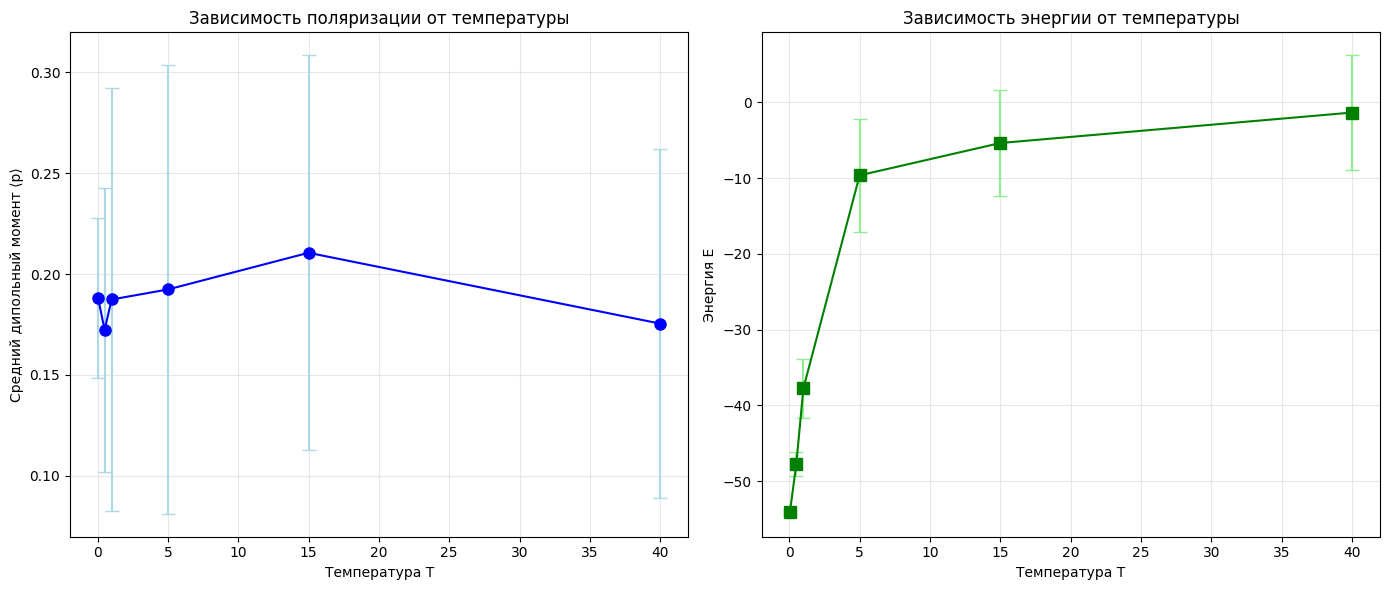

Итог
     T |          ⟨p⟩ |        σ_p |            E |        σ_E
  0.04 |       0.1881 |     0.0396 |     -54.1184 |     0.1852
  0.50 |       0.1723 |     0.0705 |     -47.6952 |     1.5751
  1.00 |       0.1874 |     0.1050 |     -37.7578 |     3.8490
  5.00 |       0.1923 |     0.1113 |      -9.6473 |     7.4162
 15.00 |       0.2105 |     0.0980 |      -5.3827 |     6.9337
 40.00 |       0.1754 |     0.0865 |      -1.3639 |     7.5603


In [100]:
if __name__ == "__main__":
    N = 5
    temperatures = [0.04, 0.5, 1.0, 5, 15, 40]
    n_runs = 40
    mc_steps = 1000
    burn_in = 200
    sigma = np.pi/8

    run_temperature_dependence(N, temperatures, n_runs, mc_steps, burn_in, sigma)